In [1]:
import sys
print(sys.executable)


C:\Users\Suthishna kumar\AppData\Local\Programs\Python\Python39\python.exe


In [2]:
!"{sys.executable}" -m pip install shap


In [3]:
import shap
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

C:\Users\Suthishna kumar\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
X_train = pd.read_csv("processed/X_train_processed.csv")
X_test = pd.read_csv("processed/X_test_processed.csv")

y_train = pd.read_csv("processed/y_train.csv").squeeze()
y_test = pd.read_csv("processed/y_test.csv").squeeze()

model = joblib.load(
    "../models/improved_decision_tree.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [5]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (1409, 65, 2)


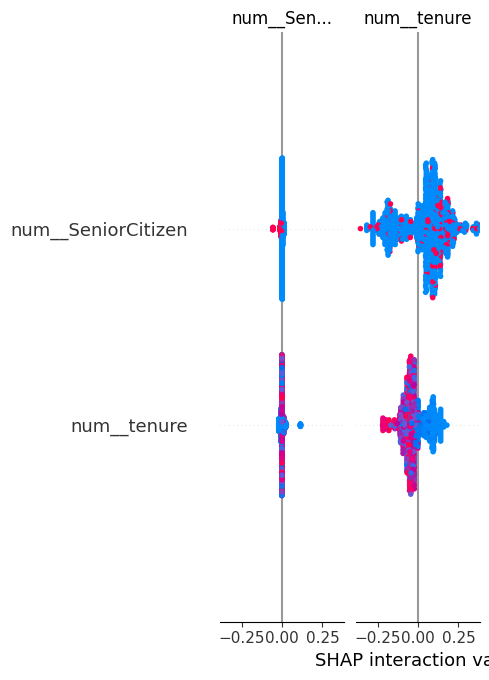

In [6]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

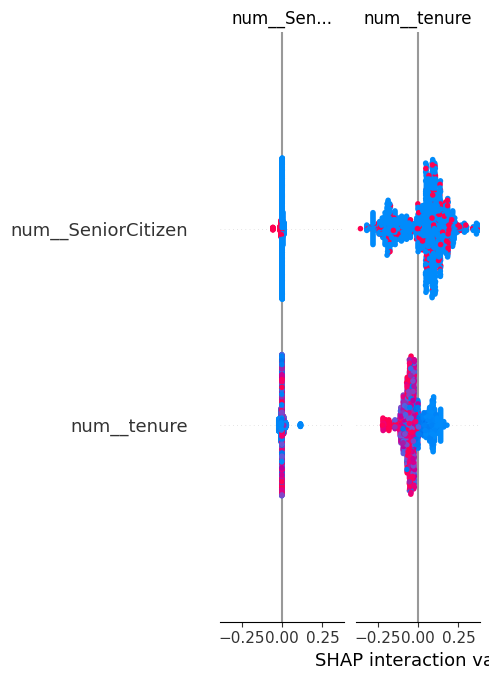

In [7]:
shap.summary_plot(
    shap_values,
    X_test
)

In [13]:
# Convert SHAP output to a NumPy array
shap_array = np.asarray(shap_values)

print("SHAP shape:", shap_array.shape)
print("X_test shape:", X_test.shape)

# Handle different SHAP output formats
if shap_array.ndim == 3:
    # For binary classification with shape:
    # (samples, features, classes)
    shap_array = shap_array[:, :, 1]

elif shap_array.ndim == 2:
    # Already in correct format:
    # (samples, features)
    pass

else:
    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_array.shape}"
    )

# Calculate mean absolute SHAP value
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# Safety check
if len(mean_abs_shap) != X_test.shape[1]:
    raise ValueError(
        f"Feature mismatch: {len(mean_abs_shap)} SHAP values "
        f"but {X_test.shape[1]} features."
    )

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_ABS_SHAP": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

SHAP shape: (1409, 65, 2)
X_test shape: (1409, 65)


,Feature,Mean_ABS_SHAP
0,cat__Contract_Month-to-month,0.203991
1,cat__InternetService_Fiber optic,0.087892
2,num__tenure,0.064311
3,num__MonthlyCharges,0.036214
4,cat__Contract_One year,0.019384
5,num__ChargeToTenure,0.016706
6,cat__PaymentMethod_Electronic check,0.015170
7,cat__MonthlyChargeGroup_Medium,0.015143
8,cat__TechSupport_No,0.015139
9,num__TotalCharges,0.014632


In [14]:
feature_importance.to_csv(
    "processed/shap_feature_importance.csv",
    index=False
)

In [15]:
customer_index = 0

customer_data = X_test.iloc[[customer_index]]

customer_shap = shap_values[customer_index]

print("Customer index:", customer_index)

Customer index: 0


Original SHAP shape: (1409, 65, 2)


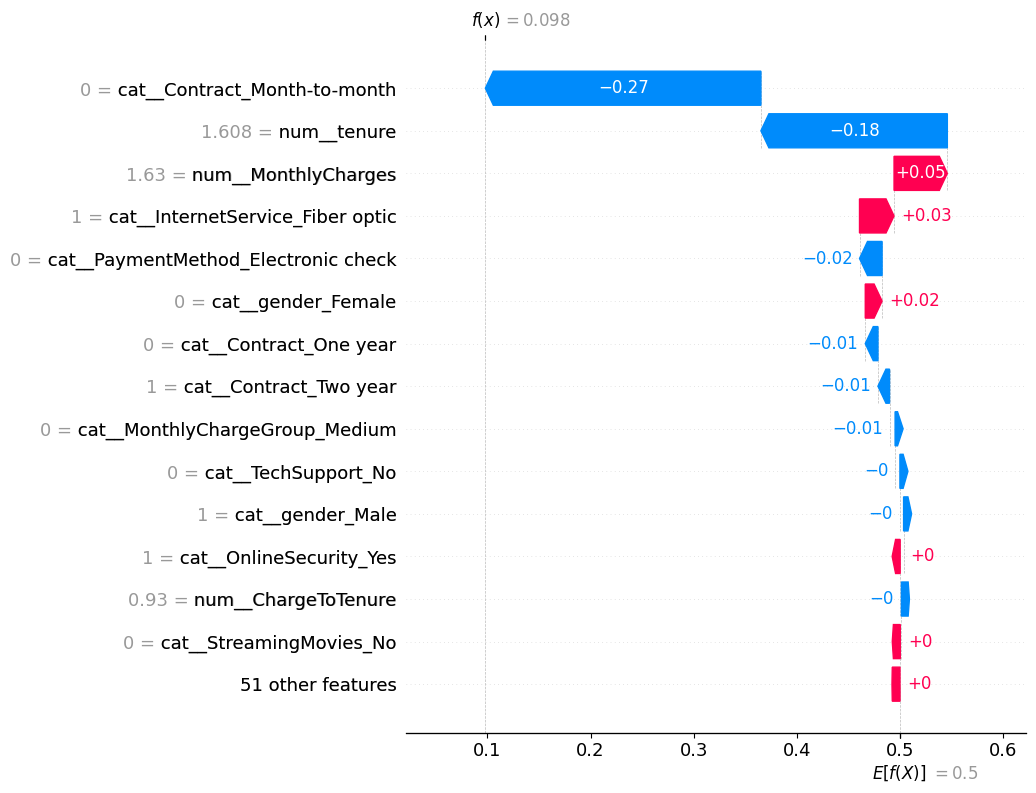

In [21]:
# Get SHAP values for one customer
customer_index = 0

# Convert SHAP output to numpy
shap_array = np.asarray(shap_values)

print("Original SHAP shape:", shap_array.shape)

# Handle binary classification output
if shap_array.ndim == 3:
    # (samples, features, classes)
    customer_shap = shap_array[customer_index, :, 1]

elif shap_array.ndim == 2:
    # Check whether this is:
    # (samples, features) OR (features, classes)

    if shap_array.shape[0] == len(X_test):
        # (samples, features)
        customer_shap = shap_array[customer_index]

    elif shap_array.shape[0] == X_test.shape[1] and shap_array.shape[1] == 2:
        # (features, classes)
        customer_shap = shap_array[:, 1]

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

else:
    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_array.shape}"
    )

# Get base value for churn class
expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    base_value = np.asarray(expected_value).flatten()[-1]
else:
    base_value = expected_value

# Customer feature values
customer_data = X_test.iloc[[customer_index]]

# Create single SHAP explanation
customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=base_value,
    data=customer_data.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Waterfall plot
shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [17]:
customer_probability = model.predict_proba(
    customer_data
)[0, 1]

print(
    f"Churn probability: {customer_probability:.2%}"
)

Churn probability: 9.79%


In [18]:
threshold = 0.55

risk = (
    "High Risk"
    if customer_probability >= threshold
    else "Low Risk"
)

print("Risk:", risk)

Risk: Low Risk


In [22]:
customer_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "FeatureValue": customer_data.iloc[0].values,
    "SHAPValue": customer_shap
})

customer_explanation["Direction"] = np.where(
    customer_explanation["SHAPValue"] > 0,
    "Increases Churn Risk",
    "Decreases Churn Risk"
)

customer_explanation = customer_explanation.sort_values(
    "SHAPValue",
    ascending=False
)

customer_explanation.head(10)

,Feature,FeatureValue,SHAPValue,Direction
2,num__MonthlyCharges,1.629976,0.051688,Increases Churn Risk
22,cat__InternetService_Fiber optic,1.000000,0.033485,Increases Churn Risk
10,cat__gender_Female,0.000000,0.016310,Increases Churn Risk
26,cat__OnlineSecurity_Yes,1.000000,0.003332,Increases Churn Risk
39,cat__StreamingMovies_No,0.000000,0.001094,Increases Churn Risk
3,num__TotalCharges,2.707614,0.000375,Increases Churn Risk
53,cat__TenureGroup_25-48 Months,0.000000,0.000269,Increases Churn Risk
46,cat__PaperlessBilling_Yes,1.000000,0.000000,Decreases Churn Risk
45,cat__PaperlessBilling_No,0.000000,0.000000,Decreases Churn Risk
41,cat__StreamingMovies_Yes,1.000000,0.000000,Decreases Churn Risk


In [23]:
top_positive = customer_explanation[
    customer_explanation["SHAPValue"] > 0
].head(5)

top_positive

,Feature,FeatureValue,SHAPValue,Direction
2,num__MonthlyCharges,1.629976,0.051688,Increases Churn Risk
22,cat__InternetService_Fiber optic,1.000000,0.033485,Increases Churn Risk
10,cat__gender_Female,0.000000,0.016310,Increases Churn Risk
26,cat__OnlineSecurity_Yes,1.000000,0.003332,Increases Churn Risk
39,cat__StreamingMovies_No,0.000000,0.001094,Increases Churn Risk


In [24]:
top_negative = customer_explanation[
    customer_explanation["SHAPValue"] < 0
].tail(5).sort_values(
    "SHAPValue"
)

top_negative

,Feature,FeatureValue,SHAPValue,Direction
42,cat__Contract_Month-to-month,0.000000,-0.267200,Decreases Churn Risk
1,num__tenure,1.608483,-0.180781,Decreases Churn Risk
49,cat__PaymentMethod_Electronic check,0.000000,-0.021896,Decreases Churn Risk
43,cat__Contract_One year,0.000000,-0.012294,Decreases Churn Risk
44,cat__Contract_Two year,1.000000,-0.011223,Decreases Churn Risk


In [27]:
def get_shap_explanation(customer_index, top_n=5):
    """
    Generate SHAP explanation for one customer
    using the improved Decision Tree model.
    """

    # Get one customer
    customer_data = X_test.iloc[[customer_index]]

    # Churn probability
    probability = model.predict_proba(customer_data)[0, 1]

    # Calculate SHAP values
    raw_shap = explainer.shap_values(customer_data)

    # Convert to numpy
    shap_array = np.asarray(raw_shap)

    print("Raw SHAP shape:", shap_array.shape)

    # Handle different SHAP output formats
    if shap_array.ndim == 3:
        # Shape could be:
        # (samples, features, classes)
        customer_shap = shap_array[0, :, 1]

    elif shap_array.ndim == 2:
        # Shape:
        # (samples, features)
        customer_shap = shap_array[0]

    elif shap_array.ndim == 1:
        customer_shap = shap_array

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )

    # Make sure it is 1-dimensional
    customer_shap = np.asarray(customer_shap).flatten()

    # Customer feature values
    feature_values = np.asarray(
        customer_data.iloc[0].values
    ).flatten()

    # Safety check
    print("Number of features:", len(X_test.columns))
    print("Number of SHAP values:", len(customer_shap))
    print("Number of feature values:", len(feature_values))

    if len(customer_shap) != len(X_test.columns):
        raise ValueError(
            f"SHAP feature mismatch: "
            f"{len(customer_shap)} SHAP values vs "
            f"{len(X_test.columns)} features."
        )

    # Create explanation dataframe
    explanation = pd.DataFrame({
        "Feature": X_test.columns,
        "FeatureValue": feature_values,
        "SHAPValue": customer_shap
    })

    # Direction
    explanation["Direction"] = np.where(
        explanation["SHAPValue"] > 0,
        "Increases Churn Risk",
        "Decreases Churn Risk"
    )

    # Positive contributors
    positive = explanation[
        explanation["SHAPValue"] > 0
    ].sort_values(
        "SHAPValue",
        ascending=False
    ).head(top_n)

    # Negative contributors
    negative = explanation[
        explanation["SHAPValue"] < 0
    ].sort_values(
        "SHAPValue",
        ascending=True
    ).head(top_n)

    return probability, positive, negative

In [28]:
probability, positive, negative = get_shap_explanation(0)

print(f"Churn probability: {probability:.2%}")

print("\nTop factors increasing risk:")
display(positive)

print("\nTop factors decreasing risk:")
display(negative)

Raw SHAP shape: (1, 65, 2)
Number of features: 65
Number of SHAP values: 65
Number of feature values: 65
Churn probability: 9.79%

Top factors increasing risk:


,Feature,FeatureValue,SHAPValue,Direction
2,num__MonthlyCharges,1.629976,0.051688,Increases Churn Risk
22,cat__InternetService_Fiber optic,1.000000,0.033485,Increases Churn Risk
10,cat__gender_Female,0.000000,0.016310,Increases Churn Risk
26,cat__OnlineSecurity_Yes,1.000000,0.003332,Increases Churn Risk
39,cat__StreamingMovies_No,0.000000,0.001094,Increases Churn Risk



Top factors decreasing risk:


,Feature,FeatureValue,SHAPValue,Direction
42,cat__Contract_Month-to-month,0.000000,-0.267200,Decreases Churn Risk
1,num__tenure,1.608483,-0.180781,Decreases Churn Risk
49,cat__PaymentMethod_Electronic check,0.000000,-0.021896,Decreases Churn Risk
43,cat__Contract_One year,0.000000,-0.012294,Decreases Churn Risk
44,cat__Contract_Two year,1.000000,-0.011223,Decreases Churn Risk


In [29]:
joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP explainer saved.")

SHAP explainer saved.
